<a href="https://colab.research.google.com/github/suchithgali/3DayProcrastinationApp/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn #contains all of pytorch's building blocks for neural networks
import matplotlib.pyplot as plt

torch.__version__

'2.9.0+cpu'

In [2]:
#creating parameters
weight = 0.7
bias = 0.3

# data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim = 1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
len(X), len(y)

(50, 50)

In [4]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [5]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions=None):

  """
  Plot training data, test data and compares predictions.
  """

  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  plt.legend(prop={"size": 14});

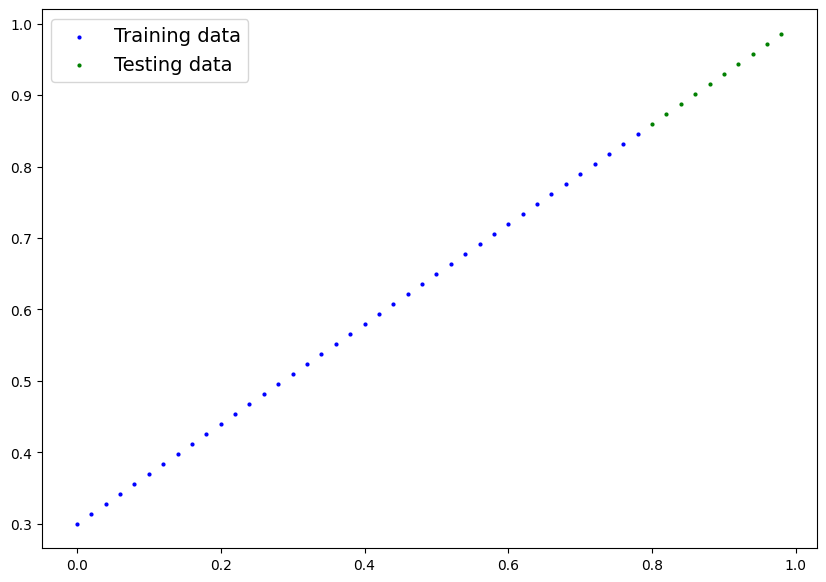

In [6]:
plot_predictions();

In [7]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.rand(1, requires_grad= True, dtype = torch.float)) #start with random values of size 1
    self.bias = nn.Parameter(torch.rand(1, requires_grad= True, dtype = torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias #linear regression

In [8]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [9]:
#when making predictions use inference mode, inference mode doesn't save gradients
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

In [10]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

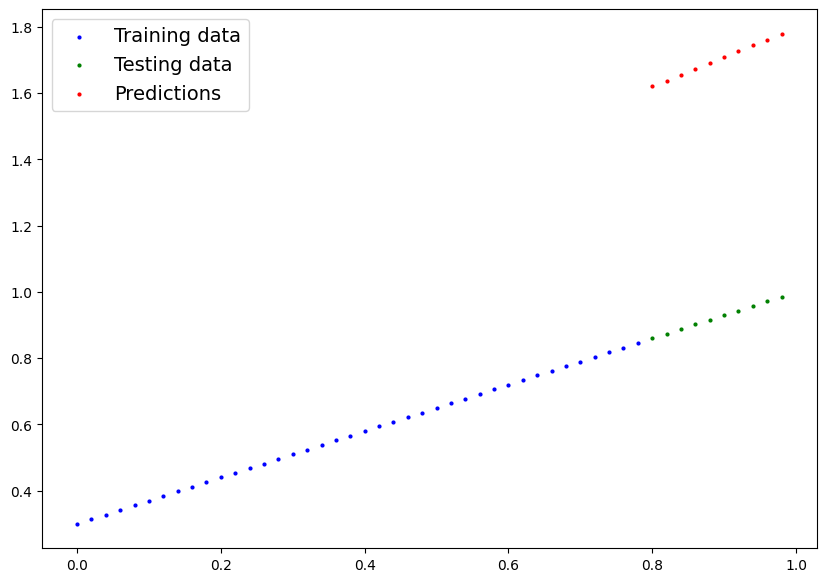

In [11]:
plot_predictions(predictions = y_preds)

In [12]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [13]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [14]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.01)

In [36]:
epochs = 100 #one loop through the data

for epoch in range(epochs):
  model_0.train() #set model to training mode, sets all parameters that require gradients to require gradients

  y_pred = model_0(X_train) #do forward propogation

  loss = loss_fn(y_pred, y_train) #calculate the loss
  print(f"Loss: {loss}")

  optimizer.zero_grad() #optimizer zero grad

  loss.backward() #perform backpropogation

  optimizer.step() #perform gradient descent, the optimizer changes will accumulate so need to 0 them above for each loop

  #model_0.eval() #turn off gradient tracking




Loss: 0.5824000239372253
Loss: 0.5708791017532349
Loss: 0.5593580603599548
Loss: 0.5478371381759644
Loss: 0.5363161563873291
Loss: 0.5247951149940491
Loss: 0.5132741332054138
Loss: 0.5017532110214233
Loss: 0.4902321696281433
Loss: 0.47871121764183044
Loss: 0.4671902060508728
Loss: 0.45566922426223755
Loss: 0.4441482126712799
Loss: 0.43262726068496704
Loss: 0.4211062490940094
Loss: 0.40958523750305176
Loss: 0.3980643153190613
Loss: 0.38654330372810364
Loss: 0.375022292137146
Loss: 0.36350134015083313
Loss: 0.3519803285598755
Loss: 0.34045934677124023
Loss: 0.328938364982605
Loss: 0.31741735339164734
Loss: 0.3058963716030121
Loss: 0.2943754196166992
Loss: 0.2828544080257416
Loss: 0.2713334262371063
Loss: 0.25981244444847107
Loss: 0.24829146265983582
Loss: 0.23677048087120056
Loss: 0.2252494841814041
Loss: 0.21372847259044647
Loss: 0.20220749080181122
Loss: 0.19068653881549835
Loss: 0.1791655272245407
Loss: 0.16764454543590546
Loss: 0.156123548746109
Loss: 0.14460256695747375
Loss: 0.1330

In [37]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6938])), ('bias', tensor([0.2980]))])

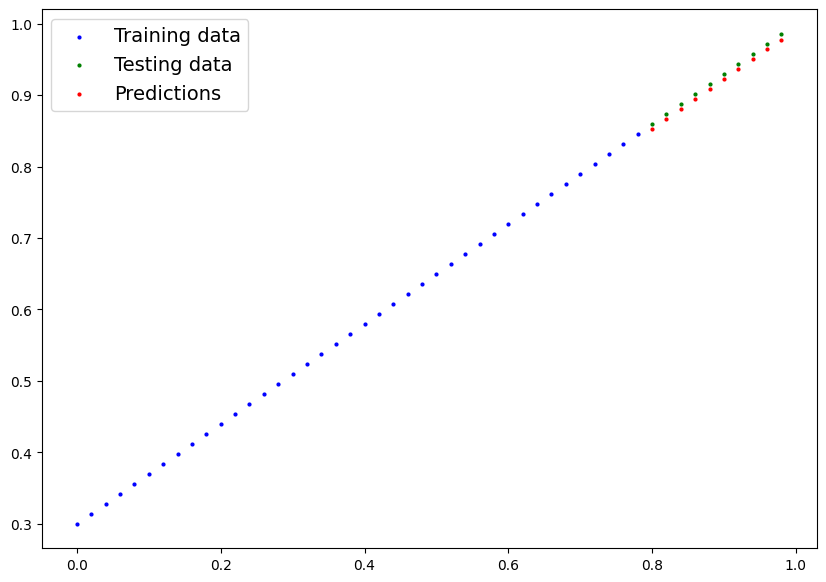

In [38]:
with torch.inference_mode():
  y_pred_new = model_0(X_test)
  plot_predictions(predictions=y_pred_new)